In [1]:
# ---- IMPORT LIBRARIES -----

import pandas as pd     # data manipulation
import numpy as np      #  allows for efficient numerical operations
import matplotlib.pyplot as plt     # visualization tool for plotting 
from sklearn.linear_model import LinearRegression   # ML algorithms, need this for linear regression

In [ ]:
# ----- LOAD AND PREPARE DATA -------

# LOAD CSVS  ... need to expand CSVs.... might include more users
budgets = pd.read_csv("budgets_test1.csv")
transactions = pd.read_csv("transactions_test1.csv")

# MERGE TABLES
data = pd.merge(transactions, budgets, on="budget_id")  # ... might change foreign key... idk... 

# SORT TRANSACTIONS BY DATE ... want user to see spending for each day
data["transaction_date"] = pd.to_datetime(data["transaction_date"])
data = data.sort_values("transaction_date")

# CUMULATIVE SPENDING FOR MONTH .... need to do weekly too
data["cumulative_spent"] = data.groupby("budget_id")["amount_x"].cumsum()

#  USING BUDGET 1 .... loop through other budgets later
budget_id = 1
budget_goal = budgets.loc[budgets["budget_id"] == budget_id, "amount"].values[0]
df = data[data["budget_id"] == budget_id]

In [ ]:
# ----- SET UP/TRAIN REGRESSION MODEL -------

# REPARE REGRESSION MODEL
X = np.arange(len(df)).reshape(-1, 1)    # .... transactions
y = df["cumulative_spent"].values

model = LinearRegression()   # ... using a simple regression model
model.fit(X, y)

# FORECAST PREDICTED SPENDING
future_spending = np.arange(len(df), len(df) + 5).reshape(-1, 1)
forecast = model.predict(future_spending)

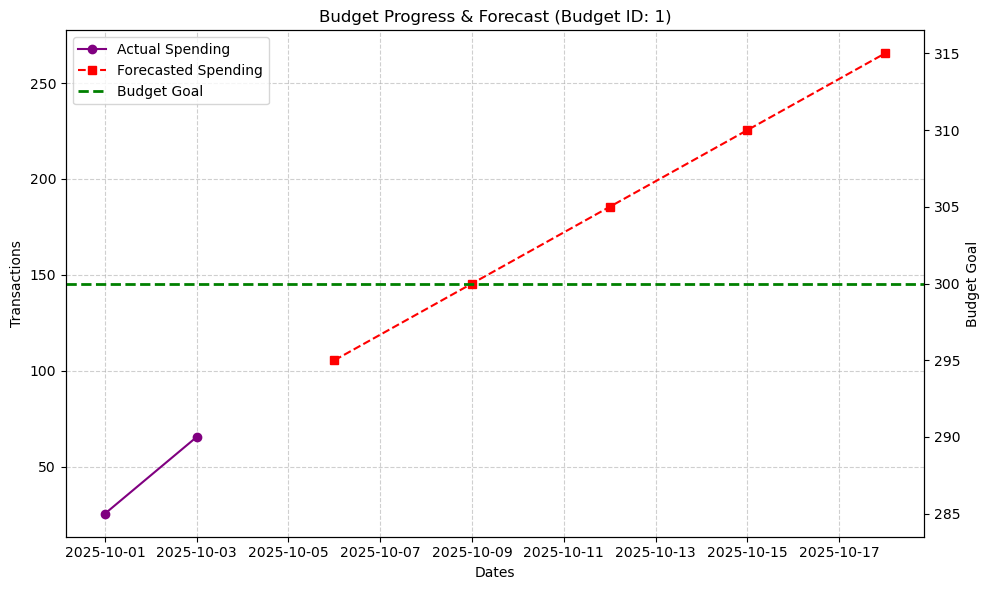

In [20]:
# ------- VISUALIZATION (just to test) ---------
# .... find different style for graph on MoneyUP UI....

# PLOTTING OUR GRAPH 
fig, ax1 = plt.subplots(figsize=(10, 6))

# PLOT CUMULATIVE SPENDING
ax1.plot(df["transaction_date"], df["cumulative_spent"], 'o-', color="purple", label="Actual Spending")     # ... try to match brand colors.... idk...

# PLOT EXTRAPOLATED SPENDING
future_dates = pd.date_range(df["transaction_date"].iloc[-1], periods=6, freq="3D")[1:]   # --- might want to extrapolate closer to last transaction... idk...
ax1.plot(future_dates, forecast, 's--', color="red", label="Forecasted Spending")  

ax1.set_xlabel("Dates")
ax1.set_ylabel("Transactions", color="black")    # .... get more familiar with methods and parameters
ax1.tick_params(axis="y", labelcolor="black")
ax1.grid(True, linestyle="--", alpha=0.6)

# RIGHT Y-AXIS FOR BUDGET GOAL .... get more familiar with methods
ax2 = ax1.twinx()
ax2.axhline(y=budget_goal, color="green", linestyle="--", linewidth=2, label="Budget Goal")  # setting horizontal line to show budget goal.... might not need it
ax2.set_ylabel("Budget Goal", color="black")
ax2.tick_params(axis="y", labelcolor="black")

# MERGE LEGENDS
lines, labels = ax1.get_legend_handles_labels()   # .... struggled on this... go back over
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper left")

plt.title(f"Budget Progress & Forecast (Budget ID: {budget_id})")
plt.tight_layout()
plt.show()